## Import the required libraries and modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


**Load the Dataset**

In [6]:
df = pd.read_csv("C:\\Users\\sanja\\anaconda_projects\\OIBSIP\\Task_2_Sales_Prediction\\Data\\Advertising.csv")
df.head(10)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8
7,8,120.2,19.6,11.6,13.2
8,9,8.6,2.1,1.0,4.8
9,10,199.8,2.6,21.2,10.6


## STEP 1: EDA

In [7]:
# Drop the unnecessary index column
df.drop(columns=['Unnamed: 0'], inplace=True)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [8]:
# Structure check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [9]:
df.shape

(200, 4)

In [10]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [11]:
# Summary statistics
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [12]:
# Inspecting missing values
miss_val = df.isnull().value_counts()
print(f'The missing values are:\n{miss_val}')

The missing values are:
TV     Radio  Newspaper  Sales
False  False  False      False    200
Name: count, dtype: int64


In [13]:
# Handling duplicate values
dup_val = df.duplicated().sum()
print(f'The number of duplicate rows : {dup_val}')  #There are no duplicate rows

The number of duplicate rows : 0


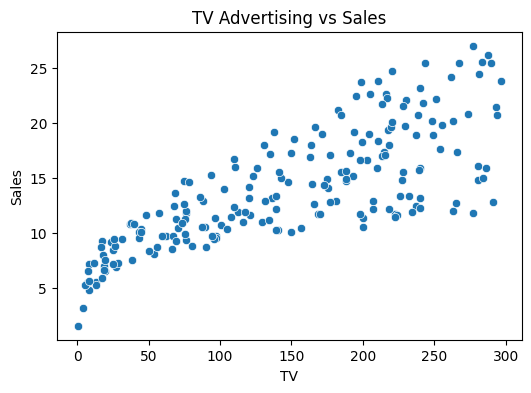

In [14]:
# Plots visualizing the relationships between features and target
plt.figure(figsize=(6, 4))
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title("TV Advertising vs Sales")
plt.show()

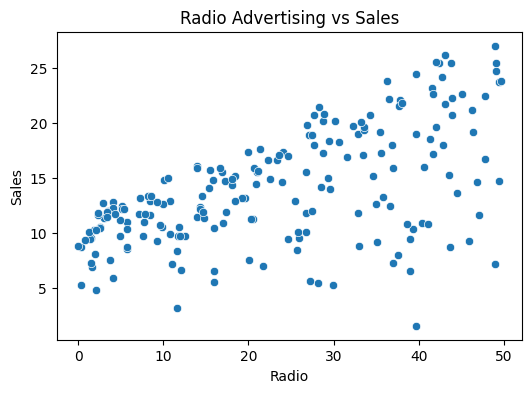

In [15]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title("Radio Advertising vs Sales")
plt.show()

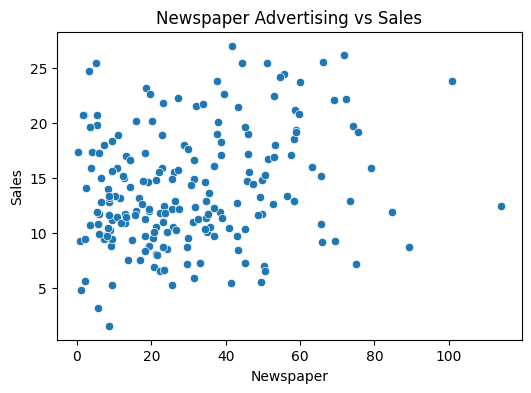

In [16]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Newspaper', y='Sales', data=df)
plt.title("Newspaper Advertising vs Sales")
plt.show()

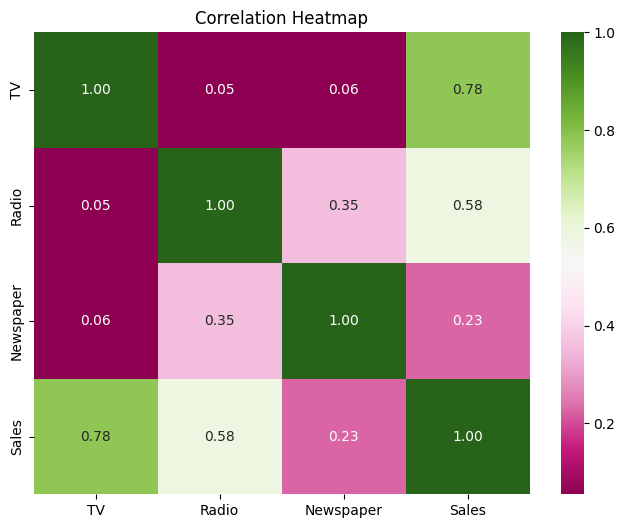

In [17]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='PiYG', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**In this sales prediction task, since the features are already numerical, no text preprocessing or vectorization is required. After EDA, we directly perform train–test split, and only apply preprocessing steps like scaling after the split to avoid data leakage.**

## STEP 2: Train-Test Split

**After EDA, features and target were separated , then a train–test split was performed to ensure the model learns only from training data and is evaluated on unseen test data. Since this is a regression problem, stratification was not required.**

In [18]:
# Define features and labels
# Features
X = df[['TV', 'Radio', 'Newspaper']]

# Target
y = df['Sales']

In [19]:
# A. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [20]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 160
Testing samples: 40


## STEP 3: Scaling

**Although Linear Regression can work without scaling, I applied StandardScaler after train–test split to avoid data leakage, improve numerical stability, and ensure fair contribution of all advertising channels. This also prepares the pipeline for regularized models like Ridge and Lasso.**

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
X_train_scaled

array([[-4.04248386e-01, -1.02823707e+00, -3.37675384e-01],
       [ 3.20607716e-01, -9.19827737e-01, -1.16143931e+00],
       [-1.27051084e+00,  2.59123702e-01,  2.54250789e-01],
       [-1.04235941e+00, -6.96233499e-01, -5.74445854e-01],
       [ 8.79103401e-01, -1.38734296e+00, -7.07629243e-01],
       [-1.32873699e+00, -1.29926038e+00, -7.96418169e-01],
       [-9.43731452e-01, -4.65863678e-01,  5.35415722e-01],
       [-3.23140256e-02,  6.94073782e-02, -5.34984109e-01],
       [-5.39713297e-01, -1.16374872e+00,  2.19721762e-01],
       [-8.75998996e-01,  3.13328366e-01, -6.87898371e-01],
       [-8.53421511e-01,  1.62101588e+00,  2.24654481e-01],
       [ 2.18414888e-01, -1.06889056e+00, -8.45745350e-01],
       [-1.67928215e+00,  1.76330312e+00,  2.22240532e+00],
       [-1.68997675e+00,  1.08574483e+00,  1.01882210e+00],
       [-8.74810708e-01, -1.49575229e+00, -7.47090988e-01],
       [-2.45017701e-01, -1.16374872e+00,  6.68075010e-02],
       [-9.10459368e-01, -3.98107848e-01

In [23]:
X_test_scaled

array([[ 0.15781217,  0.59112727,  1.13227461],
       [ 0.53925283,  1.68199613,  1.13227461],
       [ 1.69783431,  0.36753303,  0.65380096],
       [-1.64363349,  0.95023317,  0.75245532],
       [ 0.83513672,  1.77007871, -1.31928629],
       [-0.89025846,  0.82149709,  1.12240918],
       [ 0.79354661,  1.42452397, -0.13543394],
       [-1.18851892, -0.76398933, -0.56951314],
       [ 0.86009078, -1.31958713, -0.8309472 ],
       [ 0.29803023, -0.02545078,  0.07667294],
       [-1.40835233,  0.11683646, -1.36861347],
       [-1.11484502, -1.16374872, -0.01211599],
       [ 1.00387371, -1.31958713,  2.70581169],
       [-1.71849568,  0.47594236, -1.01345777],
       [-0.12500054, -1.40766971, -0.16503025],
       [ 0.23980408, -1.02146148,  0.25918351],
       [-1.69591819,  0.35398186,  0.56501203],
       [ 0.56539519,  0.02875388, -0.7766873 ],
       [-0.88788188, -0.17451361,  0.12600012],
       [ 1.03833409,  0.31332837, -0.93453428],
       [ 0.94445928,  0.63855635,  2.182

**After scaling, each feature represents how many standard deviations it lies from the mean. This ensures that TV, Radio, and Newspaper contribute fairly to the regression model without bias from differing scales.**

## STEP 4: Train the Regression Model

**What model are we training and why?**

*We used Linear Regression because:*

- Sales is a continuous number → regression problem

- Relationship between ad spend & sales is approximately linear

- Linear Regression is interpretable (very important for business)


In [24]:
# Create model
lr = LinearRegression()

# Train model on scaled training data
lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
# Make Prediction
y_pred = lr.predict(X_test_scaled)

In [27]:
y_pred

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967,
        9.04831992,  6.65328312, 14.34554487,  8.90349333,  9.68959028,
       12.16494386,  8.73628397, 16.26507258, 10.27759582, 18.83109103,
       19.56036653, 13.25103464, 12.33620695, 21.30695132,  7.82740305,
        5.80957448, 20.75753231, 11.98138077,  9.18349576,  8.5066991 ,
       12.46646769, 10.00337695, 21.3876709 , 12.24966368, 18.26661538,
       20.13766267, 14.05514005, 20.85411186, 11.0174441 ,  4.56899622])

## STEP 5: Evaluation

**I trained a Linear Regression model on standardized advertising features to predict continuous sales values. I evaluated performance using MAE, RMSE, and R², and interpreted coefficients to understand the relative influence of each advertising channel.**

In [28]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 1.4607567168117601
RMSE: 1.781599661533451
R² Score: 0.8994380241009119


In [29]:
# Model interpretation
coeff_df = pd.DataFrame({
    'Feature': ['TV', 'Radio', 'Newspaper'],
    'Coefficient': lr.coef_
})

coeff_df

,Feature,Coefficient
0,TV,3.764196
1,Radio,2.792307
2,Newspaper,0.055976


**For 1 standard deviation increase in TV spend, sales increase by 3.77 units, holding others constant.**

**The model achieved an R² of ~0.90, indicating strong explanatory power. TV and Radio showed significant positive influence on sales, while Newspaper had negligible impact. Scaling enabled fair coefficient comparison and improved interpretability.**

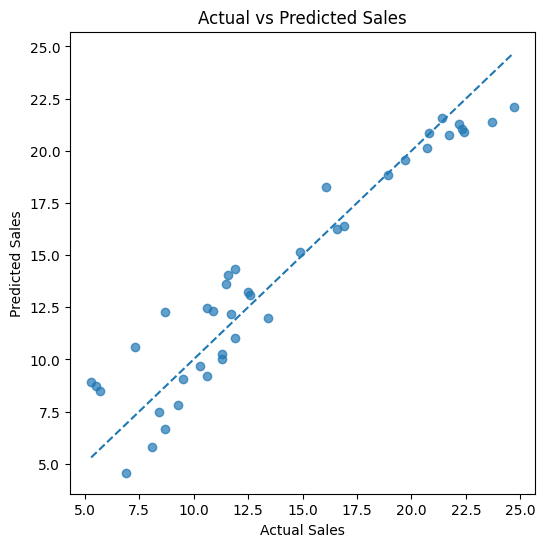

In [30]:
# y_test = actual sales values
# y_pred = predicted sales values

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

- **Each dot represents one test sample**

- **The dashed diagonal line = perfect prediction**

- **Points close to the line → good model performance**

- **The high R² (~0.90) means most points should cluster near this line as it is seen in the plot**

## 📊 Sales Prediction Using Linear Regression

This project builds a **Linear Regression model** to predict product sales based on advertising spend across **TV, Radio, and Newspaper** channels.
The goal is to understand how different marketing channels impact sales and to evaluate model performance using standard regression metrics.

### 📁 Dataset

- Features: TV, Radio, Newspaper advertising spend

- Target: Sales

### 🔍 Workflow
- Exploratory Data Analysis (EDA)
- Train–test split
- Model training using Linear Regression
- Model evaluation using **MAE, RMSE, and R²**
- Visualization of **Actual vs Predicted Sales**

### 📈 Results
- **R² Score:** 0.89 (High R² indicates the model explains most of the variance in sales)
- **TV and Radio** show the highest impact on sales
- **Newspaper** has minimal influence

### 🛠️ Tools & Libraries

- Python 
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

This project demonstrates end-to-end regression modeling, performance evaluation, and result interpretation.
